# Task 1 — Strategic Data Acquisition & Preprocessing

**Project:** Predicting Global Geopolitical Events — Impact on the USD Exchange Rate
**Hypothesis:** global geopolitical news carries significant, *predictive* information about USD exchange-rate fluctuations.

---

This notebook does not test the hypothesis. It builds the dataset that makes testing it possible — and, deliberately, makes a **false positive hard to reach**.

That second goal shapes almost everything below. It is easy to produce a pipeline that reports impressive accuracy: bin news by calendar date, shuffle the split, feed raw article counts. Each of those is a bug, each one *improves* the reported metric, and each one is invisible in the final number. So this notebook spends as much effort on guards as on acquisition.

### Route

| § | Step | Key decision |
|---|---|---|
| 1 | Configuration | every tunable is in YAML, nothing hard-coded |
| 2 | Target acquisition | USD/IDR from Bank Indonesia's JISDOR, not DXY |
| 3 | Target construction | log returns + ternary label with a dead-zone |
| 4 | News acquisition | GDELT theme codes, not keywords |
| 5 | Deduplication | collapse syndication, keep breadth as a feature |
| 6 | Filtering funnel | four stages, none of them destructive |
| 7 | Temporal alignment | WIB calendar day, paired with the next JISDOR fix |
| 8 | Preprocessing | two tracks, because preprocessing is model-dependent |
| 9 | Daily features | never a raw count |
| 10 | Assembly | the modelling table |
| 11 | Quality assurance | the checks that could still fail |
| 12 | Stage-4 human audit | the filter meets two human annotators |
| 13 | Handover to Task 2 | what is ready, what is not |

> **Run modes.** Set `OFFLINE = True` to run the whole notebook on synthetic fixtures with no network access — useful for checking the code path in ~60 seconds before committing to a live fetch. Set `STRIDE = 7` for a fast live run that samples every 7th day.

In [1]:
import sys, logging, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config" / "config.yaml").exists())
sys.path.insert(0, str(ROOT))

from src.config import load_config
from src import fx_data, gdelt, dedup, filtering, align, preprocess, features, qa
from src.http_cache import CachedSession

warnings.filterwarnings("ignore", category=FutureWarning)
logging.basicConfig(level=logging.INFO, format="%(levelname)-7s | %(name)-12s | %(message)s",
                    stream=sys.stdout, force=True)

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 9})

# ---- run mode -------------------------------------------------------------
OFFLINE = True     # True  -> synthetic fixtures, no network
STRIDE  = 7        # live runs: sample every N-th day (1 = full census)
SUB_DAY_CHUNKS = 1 # raise to 4 to relax the 250-record-per-call ceiling

# Offline runs are a SMOKE TEST of the code path, not a study. 400 sessions is
# enough to exercise every stage (including post-weekend windows and the
# rolling 90-day baselines) while keeping the notebook to about a minute.
# Set to None for the full synthetic span.
OFFLINE_DAYS = 400

cfg = load_config(ROOT / "config" / "config.yaml")
print(f"period      : {cfg.dig('period','start')} .. {cfg.dig('period','end')}")
print(f"target      : {cfg.dig('target','primary')}  ({cfg.dig('target','transform')})")
print(f"families    : {list(cfg.dig('theme_families').keys())}")
print(f"themes      : {len(cfg.all_themes)} GDELT theme codes")
print(f"seed        : {cfg.seed}   |   offline: {OFFLINE}")

period      : 2021-09-01 .. 2026-09-01
target      : USD_IDR  (log_return_pct)
families    : ['conflict', 'sanctions_trade', 'diplomacy', 'energy', 'monetary_policy', 'political_risk']
themes      : 29 GDELT theme codes
seed        : 42   |   offline: True


---
## 1. Configuration as an artefact

Every threshold, country list, theme code and window length lives in `config/config.yaml` with its rationale written beside it as a comment. There are no magic numbers in the source.

This is not tidiness for its own sake. The project rules require us to justify every architectural decision under evaluation, and **a decision we cannot point at is a decision we cannot defend**. The YAML file is the thing we point at.

In [2]:
print(open(ROOT / "config" / "config.yaml").read()[:2600], "\n... (truncated)")

# =============================================================================
# Task 1 — Strategic Data Acquisition & Preprocessing
# Project: Predicting Global Geopolitical Events — Impact on the USD Exchange Rate
#
# EVERY value in this file is a DESIGN DECISION made by the team, not a default.
# The rationale for each block is documented in docs/TASK1_REPORT.md §3-§6.
# Changing a value here changes the pipeline; nothing is hard-coded in src/.
# =============================================================================

project:
  name: geo-usd
  random_seed: 42          # fixed for every stochastic step (sampling, hashing salt)
  timezone_market: Asia/Jakarta   # FX day convention anchor — JISDOR is a WIB rate

# -----------------------------------------------------------------------------
# 1. TEMPORAL SCOPE
# Mandated by the assignment brief (Task 1, requirement 2a): "Retrieve daily
# exchange rate data for USD from 1st September 2021 - 1st September 2026."
# Exactly 5 years

---
## 2. The target — *which* dollar?

"The USD exchange rate" is under-specified, so the brief pins it down: daily USD rates for 1 September 2021 to 1 September 2026, with **Bank Indonesia as the ultimate source** (requirement 2b).

**Why not DXY or a broad basket.** The ICE Dollar Index is **57.6% euro**, so a model trained on it is largely a EUR/USD model. A broad basket has the same problem at a smaller scale. JISDOR is Indonesia's own reference rate, and it moves on Indonesia-specific news (BI policy, domestic politics, commodity exports) that a basket would dilute away.

**Acquisition.** `USD_IDR` is BI's official JISDOR export from bi.go.id, saved unmodified in `data/raw/`. It is downloaded in a browser because bi.go.id refuses scripted clients (see `src/fx_data.py`). Yahoo's `IDR=X` is fetched alongside it as `USD_IDR_YAHOO`, **only as an independent cross-check**, never as a model input.

**Controls are acquired here, not bolted on later.** DXY, VIX and Brent come from Yahoo's keyless chart endpoint in the same step. DXY asks whether a move is USD/IDR-specific or dollar-wide, VIX separates risk-off flight to the dollar from dollar-specific news, and Brent matters because Indonesia trades heavily in commodities. The honest version of our hypothesis is *"geopolitical news adds information beyond generic risk appetite and the dollar's own move"*, and without these columns we could not make that claim.

> In `OFFLINE` mode the panel below is synthetic: the `USD_IDR` level is JISDOR-scale, not the real rate.

In [3]:
if OFFLINE:
    from src.synthetic import synthetic_fx_panel
    fx_panel = synthetic_fx_panel(cfg, n_days=OFFLINE_DAYS)
else:
    fx_panel = fx_data.build_fx_panel(cfg)

trading_days = align.trading_day_calendar(fx_panel, cfg)
print(f"\nFX panel     : {fx_panel.shape[0]} rows x {fx_panel.shape[1]} series")
print(f"trading days : {len(trading_days)}  ({trading_days.min().date()} .. {trading_days.max().date()})")
fx_panel.tail(3)


FX panel     : 400 rows x 13 series
trading days : 396  (2021-09-01 .. 2023-03-14)


,USD_IDR,AFE_USD,EME_USD,DXY,EURUSD,USDJPY,GBPUSD,USDCNY,USDIDR,BRENT,GOLD,VIX,DGS10
date,,,,,,,,,,,,,
2023-03-10,15290.766333,103.231843,136.284678,91.093273,1.128512,130.001845,1.308561,7.038657,14677.842715,89.201757,2013.284808,27.680776,4.415757
2023-03-13,15321.017313,103.533362,136.635062,91.288851,1.124814,130.385275,1.306924,7.040616,14689.613451,88.286593,2005.215463,28.014607,4.421534
2023-03-14,15281.306010,103.183598,136.243539,91.142670,1.129440,129.896215,1.310167,7.035413,14637.115468,87.421923,2005.627286,28.402569,4.414871


The trading calendar is **derived from the target series' own observations**, not hard-coded. Indonesian holidays, when no JISDOR is fixed, are then handled correctly for free, and the calendar can never drift out of sync with the price series.

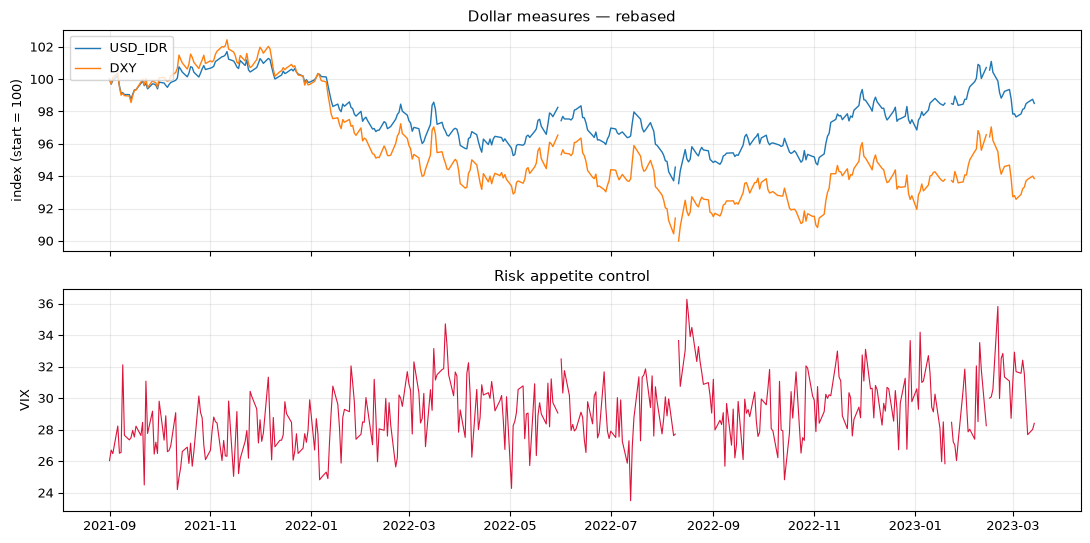

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
for c in ["USD_IDR", "DXY"]:
    if c in fx_panel:
        ax[0].plot(fx_panel.index, fx_panel[c] / fx_panel[c].dropna().iloc[0] * 100, label=c, lw=1)
ax[0].set_ylabel("index (start = 100)"); ax[0].legend(loc="upper left")
ax[0].set_title("Dollar measures — rebased")

if "VIX" in fx_panel:
    ax[1].plot(fx_panel.index, fx_panel["VIX"], lw=0.8, color="crimson")
    ax[1].set_ylabel("VIX"); ax[1].set_title("Risk appetite control")
plt.tight_layout(); plt.show()

---
## 3. From levels to a learnable target

**Log returns, not levels.** An FX index *level* is a near unit-root process. A model fed levels scores a spectacular $R^2$ by predicting "tomorrow ≈ today" while learning nothing whatsoever about geopolitics. Differencing removes that trap. Log returns are also additive across time (a 5-day return is the sum of five daily returns) and scale-free, so DXY (~100) and USDIDR (~16,000) become directly comparable.

**A ternary label with a dead-zone.** Moves smaller than 10 bp are labelled `FLAT`. Without the dead-zone the label on a quiet day is `sign(noise)`, and the model burns its capacity learning microstructure it cannot possibly predict from news.

**Exactly-unchanged fixes are kept.** A stale-quote guard makes sense for a many-decimal index, where an identical value really does mean a repeated print. JISDOR is quoted in whole rupiah, so two identical consecutive fixes happen by chance (13 of 1,202 in 2021–2026). Dropping them would punch holes in the target for no gain (`alignment.drop_zero_return_days: false`).

In [5]:
targets = fx_data.make_targets(fx_panel, cfg)
display(fx_data.describe_targets(targets, cfg).round(4))

,statistic,value
0,observations,395.0000
1,mean (%),-0.0038
2,std (%),0.3709
3,skew,0.1035
4,excess kurtosis,0.4337
5,min (%),-1.0830
6,max (%),1.3835
7,lag-1 autocorr,0.0374
8,lag-1 autocorr of |r|,0.1450
9,share UP,0.3873


Two properties to check in that table, both of which are *reassuring when they look boring*:

- **lag-1 autocorrelation of $r_t$ near zero** — the return is not predictable from its own past. If it were, we would have a momentum strategy, not a news study, and news features would be competing against a trivial baseline.
- **lag-1 autocorrelation of $|r_t|$ clearly positive** — volatility clusters, exactly as FX theory predicts. This is why `y_abs_return` is a genuinely easier auxiliary target than direction, and why Task 2 should report both.

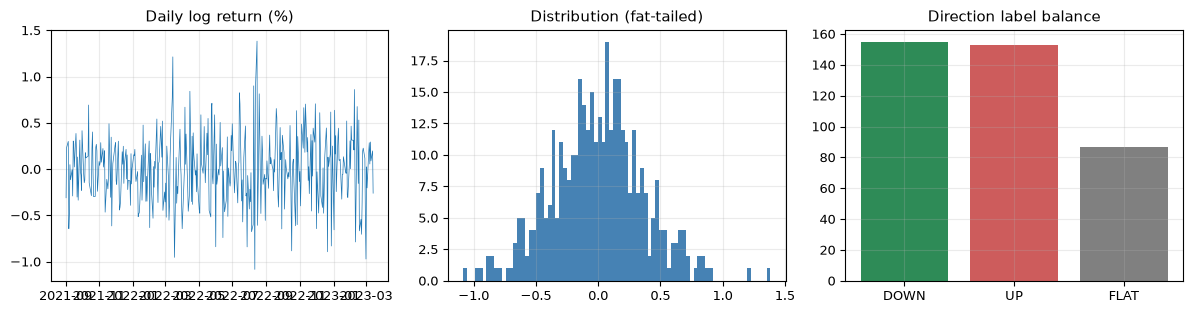

In [6]:
r = targets["y_return"].dropna()
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
ax[0].plot(r.index, r, lw=0.5); ax[0].set_title("Daily log return (%)")
ax[1].hist(r, bins=80, color="steelblue"); ax[1].set_title("Distribution (fat-tailed)")
vc = targets["y_direction"].value_counts()
ax[2].bar(vc.index.astype(str), vc.values, color=["seagreen", "indianred", "grey"])
ax[2].set_title("Direction label balance")
plt.tight_layout(); plt.show()

---
## 4. News acquisition — theme codes, not keywords

We tried the two realistic sources on the approved list, GDELT and CNBC, before choosing:

| Source | Coverage | Access | Verdict |
|---|---|---|---|
| **GDELT 2.0 GKG bulk files** | every English-language article GDELT processed, in 15-minute files | static files, keyless, no request quota | **primary** (`news_source: gkg`) |
| GDELT DOC 2.0 API | the same index, 250 records per call | per-IP quota; it blocked this project's IP for over a day in September 2026 | kept so earlier runs reproduce |
| CNBC | one newsroom | live search, about 37× slower in our timing; robots.txt disallows automated finance crawlers | rejected |

This notebook's live mode calls the DOC API (`src/gdelt.py`); the full build, `python -m src.build_dataset`, uses the GKG route (`src/gkg.py`) by default. Both select articles by the same theme codes.

### The decision that matters most: query by theme, not by keyword

A free-text keyword list drifts even over five years. "De-dollarisation" barely exists before 2022; "trade war" spikes in 2018 for reasons of *journalistic vocabulary* as much as of events. Retrieving on such a list silently makes a five-year corpus non-stationary and hands the model a spurious time trend that has nothing to do with geopolitics.

GDELT's theme taxonomy is machine-coded against a fixed codebook, so `ECON_SANCTIONS` means the same thing in 2021 and in 2026. Free-text market terms are still used — but *later*, in the Stage-2 precision gate, where they can be tuned without re-downloading anything.

### Why each theme family gets its own cap

We keep at most 250 articles per family per day. One shared cap would be filled by whichever family dominated the day, so on a heavy conflict-news day our monetary-policy articles would silently vanish. A cap per family makes the corpus composition a **design choice rather than an artefact of the cap**. In the GKG route the 250 are a seeded random draw from evenly spaced time-of-day slices, not the DOC API's "most recent 250", which biased every capped day toward late-evening coverage.

In [7]:
for fam, themes in cfg.dig("theme_families").items():
    print(f"{fam:>17} :  {gdelt.build_theme_query(themes)[:110]}")

         conflict :  (theme:ARMEDCONFLICT OR theme:MILITARY OR theme:WB_2457_TERRORISM OR theme:CRISISLEX_CRISISLEXREC OR theme:SIE
  sanctions_trade :  (theme:ECON_SANCTIONS OR theme:ECON_TRADE_DISPUTE OR theme:ECON_TARIFF OR theme:ECON_FREETRADE OR theme:WTO) s
        diplomacy :  (theme:DIPLOMATIC_COOPERATION OR theme:NEGOTIATIONS OR theme:TREATY OR theme:ALLIANCE OR theme:SUMMIT) sourcel
           energy :  (theme:ENV_OIL OR theme:ENV_GAS OR theme:ECON_OILPRICE OR theme:ENV_NUCLEARPOWER) sourcelang:english
  monetary_policy :  (theme:ECON_INTEREST_RATES OR theme:ECON_CENTRALBANK OR theme:ECON_INFLATION OR theme:ECON_CURRENCY_EXCHANGE_R
   political_risk :  (theme:ECON_UNCERTAINTY OR theme:PROTEST OR theme:ELECTION OR theme:GOVERNMENT_INSTABILITY OR theme:CORRUPTION


In [8]:
if OFFLINE:
    from src.synthetic import synthetic_articles, synthetic_timelines
    articles  = synthetic_articles(cfg, trading_days)
    timelines = synthetic_timelines(cfg, trading_days)
else:
    sess = CachedSession(Path(cfg.path("cache")),
                         sleep=cfg.dig("gdelt", "sleep_seconds", default=1.2))
    articles  = gdelt.fetch_articles(cfg, session=sess, stride_days=STRIDE,
                                     sub_day_chunks=SUB_DAY_CHUNKS)
    timelines = gdelt.timelines_to_wide(gdelt.fetch_timelines(cfg, session=sess))

print(f"\narticles fetched: {len(articles):,}")
articles.head(3)[["title", "domain", "sourcecountry", "theme_family", "seendate_utc"]]


articles fetched: 19,541


,title,domain,sourcecountry,theme_family,seendate_utc
0,Clashes erupt in Ukraine as India moves troops...,obscure-local-news.example,SA,conflict,2021-09-01 02:48:38+00:00
1,Analysis: Ukraine strikes Israel positions nea...,msn.com,CH,conflict,2021-09-01 06:55:09+00:00
2,Live: Venezuela strikes Germany positions near...,tass.com,IN,conflict,2021-09-01 16:18:54+00:00


**What we store, and why that is a legal decision as much as a technical one.** GDELT exposes headline, URL and metadata — never body text. We therefore redistribute *only* metadata and links, which keeps us clear of copyright, and we scope the NLP stack to headlines: Task 2 scores them with VADER, Loughran-McDonald and TF-IDF, with no long-document models. This is a constraint, but it is a *declared* constraint rather than a workaround.

---
## 5. Stage 3 — deduplication that keeps what it removes

A single Reuters story about an oil embargo appears in GDELT hundreds of times: mirrored by syndication partners, re-titled by aggregators, re-crawled under a different URL parameter.

Leave them in and three things break at once:

1. **"News volume" measures syndication reach**, not event importance — a quantity with no macroeconomic meaning that nonetheless trends upward over the years and is easily mistaken for signal.
2. **TF-IDF is poisoned** — a copied phrase looks like a strong repeated pattern rather than one observation.
3. **The train/test split leaks** — the same story lands on both sides.

But naive deletion throws away real information. *How widely* a story was copied is a genuine proxy for how important editors judged it to be. So we do not delete and forget: each cluster collapses to its **earliest** member (first-mover timing matters for an event study) and the cluster size survives as **`dup_count`, a feature in its own right**.

### Why SimHash and not sentence embeddings

Near-duplicate detection here is a *lexical* problem — the same sentence with a different outlet tag. SimHash over character 4-grams solves it in $O(n)$ with one 64-bit integer per document, runs on a laptop over a million headlines, and is fully deterministic, so a teammate re-running the pipeline gets byte-identical clusters.

A sentence-transformer would be slower, need a GPU, introduce a model dependency and a random seed — and, decisively, it would **over-merge**: *"Fed raises rates"* and *"Fed cuts rates"* are semantically close and are opposite events. Cheap and deterministic is the right engineering call.

All three levels apply a ±48 h window. Without it, a headline like *"Oil prices rise as tensions mount"* — which recurs verbatim every few months for years — would collapse into a single cluster, deleting a genuine repeated signal.

In [9]:
articles = dedup.deduplicate(articles, cfg)
print(f"\nduplicate rate: {articles['is_duplicate'].mean():.1%}   "
      f"clusters: {articles['cluster_id'].nunique():,}")
display(dedup.dedup_report(articles, top=6)[["title", "dup_count"]])

INFO    | src.dedup    | Stage 3 dedup: 3741/19541 flagged (19.1%) | url=0 title=2791 simhash=950 | 111281 pairs compared | 15800 clusters



duplicate rate: 19.1%   clusters: 15,800


,title,dup_count
0,Federal Reserve will not cut rates in December...,23
1,Federal Reserve will not cut rates in December...,20
2,Breaking: Federal Reserve will not cut rates i...,20
3,Federal Reserve will not cut rates in December...,19
4,Federal Reserve will not cut rates in December...,19
5,Federal Reserve will not cut rates in December...,19


**A qualitative sanity check that is worth more than it looks.** If the most-syndicated clusters are recognisable major geopolitical events, the retrieval and dedup stack is behaving. If they are horoscopes or football results, it is not — and no summary statistic would have told us.

---
## 6. The filtering funnel

"Geopolitical news that moves the dollar" is neither a keyword nor a single theme. Any **single-stage** filter fails in one of two directions:

- broad (`theme:MILITARY`) floods the corpus with military-parade coverage and video-game reviews;
- narrow (`"dollar" AND "sanctions"`) returns only articles that *already mention the outcome we are trying to predict* — which makes the "prediction" a tautology.

So: four cheap, independently auditable stages. Each writes a boolean column rather than deleting rows, so Task 2 can ablate any stage and measure what it was worth.

### Stage 0 — source gate

GDELT indexes a long tail of content farms. We use **soft** mode: non-listed domains are kept but tagged `tier=3`. Hard deletion would destroy our ability to *test* whether the gate helped, and would bias coverage against non-Western outlets that simply are not on our (inevitably Anglophone) allowlist.

State-affiliated outlets (TASS, RT, Xinhua, Global Times, Press TV) are **kept on purpose** and flagged. They publish propaganda — but propaganda is itself a geopolitical signal, and a framing shift in TASS is information. Excluding them would leave us with only the Western narrative of every event, which is a bias, not a cleaning step.

### Stage 2 — materiality gate

An article passes if **any** of three conditions holds: a G20 / reserve-currency / pivotal actor country; a monetary, trade or security institution in the headline; or an explicit market term.

**Why OR and not AND.** AND would be far more precise and badly wrong. The articles with the most predictive value are often the ones that do *not* yet mention the dollar — by the time a headline reads *"dollar rises on sanctions news"*, the move has already happened and there is nothing left to predict. Requiring a market term would select for **post-hoc explanation articles** and manufacture exactly the reverse-causality problem we have to guard against.

In [10]:
articles = filtering.run_funnel(articles, cfg)
display(filtering.funnel_report(articles))

INFO    | src.filtering | Stage 0 source gate (soft): pass 15975/19541 (81.8%) | tier1 7170 tier2 7011 tier3 5360 | blocked 3566


INFO    | src.filtering | Stage 2 materiality gate: pass 19541/19541 (100.0%) | country 100.0% institution 11.3% market-term 22.0%


,stage,removed,surviving,pct_of_raw
0,0. Retrieved from GDELT (post-thematic query),19541,19541,100.000000
1,0a. minus blocklisted domains,3566,15975,81.751190
2,0b. minus source-gate rejects,3566,15975,81.751190
3,2. minus non-material,0,15975,81.751190
4,3. minus duplicates,3002,12973,66.388619


In [11]:
display(filtering.family_balance(articles))

,raw,kept,retention_%,share_raw_%,share_kept_%
theme_family,,,,,
sanctions_trade,3304,2326,70.4,16.9,17.9
diplomacy,3294,2294,69.6,16.9,17.7
energy,3283,2276,69.3,16.8,17.5
conflict,3152,2200,69.8,16.1,17.0
political_risk,3335,2176,65.2,17.1,16.8
monetary_policy,3173,1701,53.6,16.2,13.1


That second table is the check for a specific silent failure: **a filter that wipes out one theme family has changed the research question without anyone noticing.** If `monetary_policy` retention collapses while `conflict` survives intact, we are no longer testing the hypothesis we wrote down.

---
## 7. Temporal alignment — the section that decides whether any of this is valid

Almost every published failure of "news predicts markets" research is a misalignment bug, not a modelling bug. There are exactly three ways to get it wrong, and **all three make the backtest look better**, which is why they survive code review.

**1 · Same-day pairing.** Join news from day D to the rate fixed on day D. A story published at 20:00 WIB then sits next to that day's JISDOR, which BI had already fixed that afternoon, so the story "predicts" a number that existed before it did. Silent, devastating look-ahead. Taking the date in UTC instead of WIB makes it worse, because it moves late-UTC stories (much US news) onto the wrong day.

**2 · Weekend and holiday leakage.** JISDOR is not fixed on weekends or Indonesian holidays. Naive resampling either drops that news entirely — losing precisely the geopolitical events that governments time for a Friday night — or attaches it to a day with no rate.

**3 · Contemporaneous "prediction".** Using news from day $t$ to explain the return of day $t$ is a *nowcast*, not a forecast, and it cannot distinguish "news moved the dollar" from "the dollar moved, so journalists wrote about it".

### Our convention: a day-level rule in WIB

JISDOR is fixed once per Indonesian business day, but its publication time was not constant over the period. Rather than defend a different intraday cutoff for each regime, we use a rule that never needs to know the fixing time:

1. Convert GDELT's UTC timestamp to WIB (UTC+7, no daylight saving) **first**, then take the calendar date D.
2. Bucket the article on the last trading day on or before D, so Friday + Saturday + Sunday news share one bucket.
3. Shift every bucket forward one trading day (`predict_lag_days: 1`).

Net effect: news from WIB day D is paired with **the first JISDOR fix strictly after D**, and everything that piled up while the market was closed meets the same next fix. The fix a story is paired with was always set after the story existed, whichever fixing-time regime was in force.

We use GDELT's `seendate` (crawl time), not the article's self-declared publication date. `seendate` is weakly *later* than true publication, so any error it introduces is **conservative**: it can delay a story into a later window, never leak it into an earlier one.

Weekend news accumulates into one bucket that meets Monday's fix, and `window_hours` is exposed as a feature. Otherwise the model reads that mechanically larger bucket (about 72 h instead of 24 h) as a genuine news spike, every single week.

In [12]:
articles = align.attach_news_day(articles, trading_days, cfg)
w = articles.groupby("news_day")["window_hours"].first()
print(f"window length: median {w.median():.0f}h   |   >30h (post-weekend): "
      f"{(w > 30).mean():.1%} of sessions")
articles[["title", "seendate_utc", "news_day", "window_hours", "is_post_weekend"]].head(4)

window length: median 24h   |   >30h (post-weekend): 21.0% of sessions


,title,seendate_utc,news_day,window_hours,is_post_weekend
0,Live: Venezuela government faces no-confidence...,2021-08-31 23:57:14+00:00,2021-09-01,24.0,False
1,Clashes erupt in Ukraine as India moves troops...,2021-09-01 02:48:38+00:00,2021-09-01,24.0,False
2,Live: Venezuela government faces no-confidence...,2021-09-01 03:08:10+00:00,2021-09-01,24.0,False
3,Breaking: Russia government faces no-confidenc...,2021-09-01 03:47:08+00:00,2021-09-01,24.0,False


This is asserted, not assumed. `tests/test_pipeline.py` checks the rule directly: 16:59 UTC on Tue 5 Mar 2024 (23:59 WIB) is Tuesday's news, while 18:30 UTC the same day (01:30 WIB Wed) is Wednesday's; Fri + Sat + Sun news shares one bucket and meets Monday's fix; and news during the Idul Fitri 2024 closure (8–12 Apr) meets the 15 Apr fix.

In [13]:
import subprocess
print(subprocess.run([sys.executable, str(ROOT / "tests" / "test_pipeline.py")],
                     capture_output=True, text=True, cwd=str(ROOT)).stdout[-1400:])

PASS  test_chronological_split_does_not_overlap
PASS  test_dedup_keeps_the_earliest_member_and_records_cluster_size
PASS  test_entity_aliases_collapse_to_one_symbol
PASS  test_full_offline_pipeline_produces_a_clean_frame
PASS  test_holiday_news_rolls_to_the_next_fix
PASS  test_horizon_targets_are_cumulative_forward_sums
PASS  test_identical_headline_far_apart_is_not_deduplicated
PASS  test_materiality_gate_is_or_not_and
PASS  test_negation_survives_track_a
PASS  test_numbers_become_typed_placeholders
PASS  test_prediction_frame_has_no_contemporaneous_market_column
PASS  test_simhash_near_duplicates_are_close_and_opposites_are_not
PASS  test_source_gate_blocks_farms_and_tiers_wires
PASS  test_track_b_preserves_case_and_function_words
PASS  test_utc_is_converted_to_wib_before_taking_the_date
PASS  test_weekend_news_shares_fridays_bucket_and_mondays_fix

16/16 passed



---
## 8. Preprocessing — two tracks, because preprocessing is model-dependent

The reflex answer to "preprocess the text" is: lowercase, strip punctuation, remove stopwords, lemmatise. Applied to VADER, which reads capitals, "!" and "not", that reflex throws away exactly what it reads, and for a sentiment task it can be simply **wrong**.

**Failure 1 — negation destruction.**

> `"Fed will not cut rates"` → standard NLTK stopword removal → `"fed cut rates"`

The sentiment has inverted and the economic meaning is now the opposite of the source. Our Track-A configuration therefore carries an explicit **keep-list** of negators and directional words (`not`, `no`, `never`, `against`, `up`, `down`, …). It is the single highest-value line in the config file.

**Failure 2 — casing as information.** "US" (the country) versus "us" (the pronoun); "Fed" versus "fed". Lowercasing merges them.

So: one corpus, two **views** of it.

| | Track A — TF-IDF, Loughran-McDonald | Track B — VADER |
|---|---|---|
| unicode repair | ✔ | ✔ |
| strip outlet suffix | ✔ | ✔ |
| lowercase | ✔ | ✘ casing carries entity information and emphasis |
| remove stopwords | ✔ *with keep-list* | ✘ negators and function words carry meaning |
| lemmatise | ✔ | ✘ words stay as written |
| number masking | `<NUM>` / `<PCT>` / `<MONEY>` | ✘ |

Both tracks share one pre-step: **entity canonicalisation**. "U.S.", "US", "United States" and "Washington" become one symbol — otherwise the country with the most aliases looks like four rare entities instead of one dominant one.

**On number masking.** The exact figure "4.25%" is a hapax that TF-IDF cannot use, but *the presence of a percentage in a headline* is a strong signal that it is a rate or inflation story. Masking keeps the signal, drops the noise, and removes thousands of useless vocabulary types.

In [14]:
display(preprocess.demo_negation_failure())

,original,naive_stopword_removal,ours_with_keeplist
0,Fed will not cut rates in December,fed cut rates december,fed not cut rates december
1,Sanctions are not expected to be lifted,sanctions expected lifted,sanctions not expected lifted
2,China says it will never devalue the yuan,china says devalue yuan,china says never devalue yuan
3,Oil prices down as OPEC talks collapse,oil prices opec talks collapse,oil prices down opec talks collapse


In [15]:
articles = preprocess.preprocess_frame(articles, cfg)
display(preprocess.preprocessing_examples(articles, n=6))

WARNING | src.preprocess | NLTK stopwords corpus not downloaded; using fallback list. Run: python -m nltk.downloader stopwords wordnet omw-1.4


WARNING | src.preprocess | WordNet unavailable; using the suffix-rule lemmatizer fallback


INFO    | src.preprocess | preprocess: 19541 rows | track A median 9 tokens (0 emptied by min_tokens) | track B median 11 tokens


,title,text_track_a,text_track_b
0,Report: China says it will not de-escalate ten...,report china say not de escalate tension saudi...,Report: China says it will not de-escalate ten...
1,OPEC weighs output cut after China-Germany ten...,opec weigh output cut after china,OPEC weighs output cut after China
2,Exclusive: United States envoy arrives in Chin...,exclusive united_state envoy arrive china nego...,Exclusive: United States envoy arrives in Chin...
3,Israel government faces no-confidence vote ami...,israel government face no confidence vote amid...,Israel government faces no-confidence vote ami...
4,Analysis: United States imposes new tariffs on...,analysi united_state impose new tariff saudi a...,Analysis: United States imposes new tariffs on...
5,Update: Venezuela says it will never accept Uk...,update venezuela say never accept ukraine trad...,Update: Venezuela says it will never accept Uk...


---
## 9. Daily features — never a raw count

One principle governs every feature:

> **A raw article count is not a feature.**

GDELT's indexed source list expanded materially around 2018, and our own per-family daily cap truncates busy days. Both put non-stationary, non-economic trend into raw volume. A model fed raw counts will learn *"later years have more articles"* and call it signal.

So every volume feature is expressed **relatively**:

- **z-score against a trailing 30/90-day window** — "is today unusual *for this era*?"
- **share of the day's total** — composition, immune to level shifts
- **`articles_per_24h`** — corrects for the 65-hour Monday window
- **`log1p`** — tames the heavy right tail

Beyond volume:

- **`syndication_*`** — recovered from the dedup stage; the newsroom's own importance vote
- **`theme_entropy`, `geo_entropy`, `geo_hhi`** — *concentration*. Low entropy means the day's news is focused on one country or one theme (a single large event); high entropy means diffuse background chatter. One big shock moves markets; a hundred small stories do not.
- **`share_tier1`, `share_state_media`** — who is doing the reporting
- **`gdelt_volume_*`** — daily volume counted **before** the cap, our control for it

All rolling statistics are trailing and are computed *before* the alignment shift, so no future information can enter a feature. That is enforced by assertion, not assumed.

In [16]:
feats = features.build_daily_features(articles, cfg, timeline_wide=timelines)
feats = features.reindex_to_trading_days(feats, trading_days)
print(f"daily features: {feats.shape[0]} days x {feats.shape[1]} columns")
display(features.feature_dictionary(feats).groupby("group")
        .agg(n_columns=("column", "size")).sort_values("n_columns", ascending=False))

INFO    | src.features | daily features: 396 days x 53 columns (2021-09-01..2023-03-14)


daily features: 396 days x 53 columns


,n_columns
group,
GDELT uncapped volume,12
theme/materiality share,9
theme intensity (relative),6
GDELT tone,6
volume,5
source composition,4
syndication breadth,3
calendar,2
volume (relative),2


**Zero-fill, not forward-fill**, for genuinely newsless days. A day with no matching articles really had none. Forward-filling would invent yesterday's news flow and — worse — smear an event across days, blurring exactly the event-study timing the hypothesis depends on.

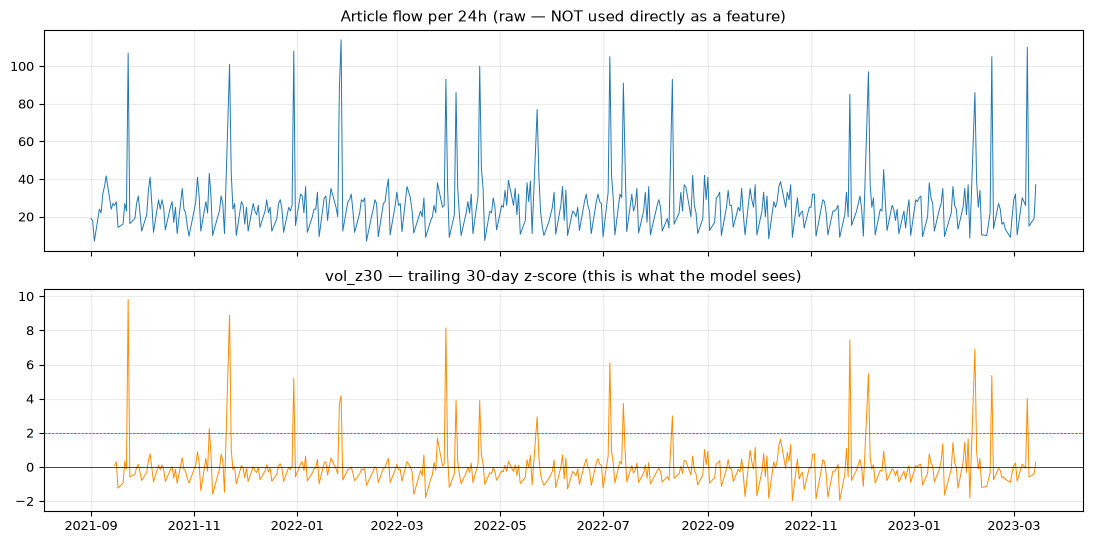

In [17]:
fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
ax[0].plot(feats.index, feats["articles_per_24h"], lw=0.7)
ax[0].set_title("Article flow per 24h (raw — NOT used directly as a feature)")
ax[1].plot(feats.index, feats["vol_z30"], lw=0.7, color="darkorange")
ax[1].axhline(0, color="k", lw=0.5); ax[1].axhline(2, color="r", lw=0.5, ls="--")
ax[1].set_title("vol_z30 — trailing 30-day z-score (this is what the model sees)")
plt.tight_layout(); plt.show()

---
## 10. Assembly — and the leak we actually found

The features are shifted forward by one session and joined to the targets.

**This step caught a real bug on the first run.** At the time the target was a broad dollar index, and the target frame contained its own return, `ret_BROAD_USD`, which is *numerically identical* to `y_return`. (With the JISDOR target the same column is `ret_USD_IDR`, and the same guard covers it.) Joined naively, it handed the model its own answer under a different name and produced a flawless, worthless $R^2$ — and the leakage assertions flagged it immediately:

```
LEAKAGE CHECK FAILED: features with |corr| > 0.95 vs target:
['ret_BROAD_USD', 'ret_AFE_USD', 'ret_DXY', 'ret_EURUSD', ...]
```

Market history is genuinely useful — momentum and volatility are standard controls, and Task 4 needs them to show that news adds information *beyond price itself*. But only from the past. So every market column is now lagged exactly like the news features and renamed with a `lag1_` prefix that makes its timing **visible in any coefficient table**.

That is the argument for keeping this check in the pipeline rather than in a code review: a reviewer reading a 79-column frame would not have spotted it.

In [18]:
dataset = align.make_prediction_frame(feats, targets, cfg)
dataset = align.chronological_split(dataset, cfg)

print("\nsplit boundaries:")
for s in ("train", "val", "test"):
    ix = dataset.index[dataset["split"] == s]
    if len(ix):
        print(f"  {s:5s} {len(ix):5d} rows   {ix.min().date()} .. {ix.max().date()}")

INFO    | src.align    | prediction frame: 396 rows x 79 cols, lag=1, 2021-09-01..2023-03-14


INFO    | src.align    | chronological split: {'train': 396}



split boundaries:
  train   396 rows   2021-09-01 .. 2023-03-14


**Chronological splits, never shuffled.** A random split on autocorrelated data lets the model interpolate between a Monday and a Wednesday it has already seen to "predict" the Tuesday in between. The resulting accuracy is real and completely meaningless.

In [19]:
problems = align.leakage_assertions(dataset, cfg)
print("LEAKAGE ASSERTIONS:", "ALL PASSED" if not problems else "FAILED")
for p in problems:
    print("  -", p)

INFO    | src.align    | leakage assertions: all passed


LEAKAGE ASSERTIONS: ALL PASSED


---
## 11. Quality assurance

Every check below exists because of a specific, named way this dataset can lie to us. A QA suite that just prints `df.describe()` catches none of them.

In [20]:
display(qa.validity_summary(articles, feats, targets, problems))

,check,status,detail
0,Corpus non-empty after filtering,PASS,"12,973 articles kept"
1,News coverage of trading days >= 90%,PASS,100.0% of trading days
2,"Target series usable (>1,000 obs)",FAIL,395 daily returns
3,No degenerate class (<5%),PASS,"DOWN 39%, UP 39%, FLAT 22%"
4,Duplicate rate under control (<60%),PASS,19.1% flagged duplicate
5,No leakage assertion failures,PASS,all checks passed


In [21]:
display(qa.coverage_report(feats, trading_days))

,year,trading_days,days_with_rows,days_with_articles,coverage_%,median_articles
0,2021,88,88,88,100.0,27.0
1,2022,258,258,258,100.0,29.0
2,2023,50,50,50,100.0,29.0


### The cap-saturation check, and why it is the subtlest one here

When a family hits its 250-article cap, we did **not** see that day in full — we kept 250 of its articles.

Saturation is *correlated with news intensity*, which is precisely our predictor. So the measurement error is **not random noise; it is systematic censoring that compresses exactly the big-news days the hypothesis cares about**. If saturation is common, the honest fixes are to raise the cap (`gkg.per_family_daily_cap`) or to lean on the volume counted before the cap. This table tells us which.

In [22]:
sat = qa.cap_saturation_report(articles)
display(sat if not sat.empty else "no per-request accounting available")

,theme_family,requests,saturated,median_n,max_n,saturation_%
0,conflict,394,0,7.0,44,0.0
1,diplomacy,395,0,7.0,39,0.0
2,energy,394,0,7.0,40,0.0
3,monetary_policy,395,0,7.0,40,0.0
4,political_risk,396,0,7.0,39,0.0
5,sanctions_trade,396,0,7.0,43,0.0


In [23]:
display(qa.structural_break_report(feats))

,year,median,mean,std,count,yoy_median_ratio
0,2021,24.0,26.253788,16.911534,88,NaN
1,2022,25.0,27.473514,16.582702,258,1.04
2,2023,25.5,28.116667,20.569506,50,1.02


Yearly median volume is the **GDELT crawler-expansion check**. If the medians jump by a factor unrelated to world events, raw counts are contaminated and only relative features may be used downstream. This table is the evidence for that decision — not a hunch about it.

In [24]:
display(qa.fx_sanity_report(targets))
display(qa.corpus_quality_report(articles))

,check,value,status
0,observations,395.0000,THIN
1,exact-zero returns,0.0000,OK
2,|return| > 5 sigma,0.0000,OK
3,|return| > 3% in a day,0.0000,OK
4,excess kurtosis,0.4300,unusually thin-tailed
5,lag-1 autocorrelation,0.0374,OK: near-zero as theory predicts
6,lag-1 autocorr of |r|,0.1450,expected: volatility clusters


,check,value,pct_of_total
0,total rows fetched,19541,100.00
1,unique URLs,19541,100.00
2,flagged duplicate,3741,19.14
3,missing/blank title,0,0.00
4,non-English language tag,0,NaN
5,empty after Track-A preprocessing,0,0.00
6,survived the full funnel,12973,66.39
7,distinct domains,11,NaN
8,distinct source countries,12,NaN


---
## 12. Stage 4 — the human audit

Stages 0–3 are **our opinion** about what a dollar-relevant geopolitical article is, expressed as code. The audit is where that opinion meets evidence.

Two annotators independently label a stratified sample of 300 articles drawn from **both sides** of the filter — auditing only what we kept would measure precision and be blind to recall, and a filter that discards half the real signal is exactly as broken as one that keeps garbage.

```bash
python scripts/make_audit_sample.py build
# ... two team members label reports/audit_annotator_{A,B}.csv independently ...
python scripts/make_audit_sample.py score --a reports/audit_annotator_A.csv \
                                          --b reports/audit_annotator_B.csv
```

Three numbers come out, and **the order in which we read them matters**:

1. **Cohen's $\kappa$ first.** If two humans cannot agree on what "material" means, the label is ill-defined and no precision figure computed from it means anything. Raw agreement will not do: two annotators who both answer "1" 90% of the time agree 82% of the time by luck alone.
2. **Precision** — of what the filter kept, what share is genuinely material?
3. **Recall** — of what it discarded, what share should have been kept?

Acceptance thresholds, fixed in the config *before* seeing any results: $\kappa \ge 0.60$, precision $\ge 0.85$. Stratification is by (year × theme family), because a simple random sample would be dominated by the largest family in the busiest years and would say nothing about whether the filter behaves **consistently across the five years** — which is the failure mode we are actually worried about.

The annotators never see the filter's own verdict. Showing it would anchor them and make the audit worthless.

---
## 13. Handover to Task 2

### Ready

- `data/processed/dataset.parquet` — one row per trading day, lagged news features + labels + chronological split
- `data/interim/articles_flagged.parquet` — article-level text in both preprocessing tracks, ready for TF-IDF and Loughran-McDonald (Track A) or VADER (Track B)
- Every filter decision preserved as a boolean column, so **any stage can be ablated** and its contribution measured
- 16 property tests covering alignment, leakage, negation handling and dedup

### Baselines Task 2 must beat

Any model has to outperform all three, or the result means nothing:

1. **Always predict the majority class** — surprisingly strong with a `FLAT` dead-zone
2. **Lagged market features only** (`lag1_*`) — no news at all; this is the honest test of whether news adds *anything*
3. **News volume z-score only** — one feature, no NLP; if an NLP model cannot beat it, the NLP is decorative

### Open threats, carried forward deliberately

| Threat | Status | Where it must be resolved |
|---|---|---|
| **Reverse causality** — FX moves cause news | mitigated by the OR-gate design, *not eliminated* | Task 4: lead-lag and Granger tests |
| English-source skew | flagged (`state_affiliated`, `sourcecountry`) | Task 3: multilingual ablation |
| 250-article daily cap per family | measured; volume counted before the cap | Task 2: raise the cap if saturation is high |
| Coverage ≠ market impact | unresolved by design | Task 4: interpret with care |
| Daily granularity | structural | acknowledge; no intraday causal claim is available |

### The honest statement of what this dataset can support

This pipeline can establish **daily-horizon predictability** and can test whether news features add information beyond price and generic risk appetite. It **cannot** establish intraday causality, and it cannot rule out that a portion of any measured relationship runs from markets to news rather than the other way round.

Saying so now is not hedging. It is what stops Task 4 from overclaiming — and a Task 4 that overclaims is the most likely way this project goes wrong.